# 1_Cálculo del valor de decisión óptimo para el caso de una regla de decisión ML en una observación continua


## Consigna

Considere el siguiente problema de prueba de hipótesis entre dos hipótesis igualmente probables. Bajo la hipótesis $H=0$, la señal observable $Y$ es igual a $a + Z$ donde $Z$ es una variable aleatoria con distribución laplaciana

$$
f_Z(z) = \frac{1}{2} e^{-\lvert z - \mu \rvert}
$$

donde $\mu$ es la media de la variable $Z$.

Bajo la hipótesis $H=1$, $Y$ viene dado por $-a + Z$. Se supone que $a>0$.

1. Realice un programa en una Jupyter Notebook que dibuje las funciones de densidad de probabilidad $f_{Y\mid H}(y\mid 0)$ y $f_{Y\mid H}(y\mid 1)$.
2. Determine cualitativamente el nivel de decisión óptimo. ¿Bajo qué regla de decisión es óptimo?
3. Determine cuantitativamente el nivel de decisión óptimo.
4. Determine cuantitativamente la probabilidad de error $P_e$.


## Resolución

Como las hipótesis son igualmente probables, la regla que minimiza la probabilidad de error es la **regla ML**. En este problema, el ruido no es gaussiano sino **laplaciano**, pero la lógica de comparación entre densidades sigue siendo la misma.

Además, conviene notar que esta versión es una generalización del ejercicio del libro. Si se toma $\mu = 0$, se recupera el caso estándar con densidad

$$
f_Z(z) = \frac{1}{2} e^{-\lvert z \rvert}.
$$


### 1. Expresión matemática de $f_{Y\mid H}(y\mid 0)$ y $f_{Y\mid H}(y\mid 1)$

Bajo $H=0$ se tiene

$$
Y = a + Z.
$$

Entonces, la densidad condicional se obtiene desplazando la densidad de $Z$ en $a$ unidades hacia la derecha:

$$
f_{Y\mid H}(y\mid 0) = f_Z(y-a) = \frac{1}{2} e^{-\lvert (y-a)-\mu \rvert} = \frac{1}{2} e^{-\lvert y-(\mu+a) \rvert}.
$$

Bajo $H=1$ se tiene

$$
Y = -a + Z.
$$

Entonces:

$$
f_{Y\mid H}(y\mid 1) = f_Z(y+a) = \frac{1}{2} e^{-\lvert (y+a)-\mu \rvert} = \frac{1}{2} e^{-\lvert y-(\mu-a) \rvert}.
$$

Conclusión:

$$
f_{Y\mid H}(y\mid 0) = \frac{1}{2} e^{-\lvert y-(\mu+a) \rvert},
$$

$$
f_{Y\mid H}(y\mid 1) = \frac{1}{2} e^{-\lvert y-(\mu-a) \rvert}.
$$


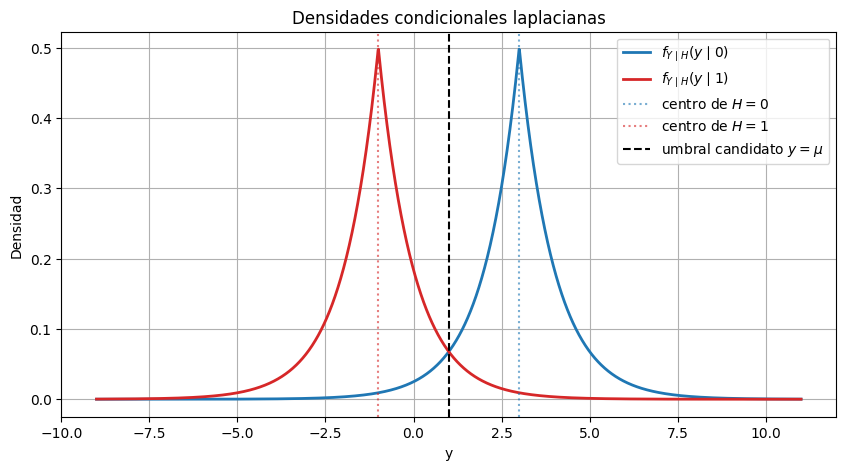

In [1]:
import numpy as np
import matplotlib.pyplot as plt

mu = 1.0
a = 2.0

def f_y_given_h0(y, mu, a):
    return 0.5 * np.exp(-np.abs(y - (mu + a)))

def f_y_given_h1(y, mu, a):
    return 0.5 * np.exp(-np.abs(y - (mu - a)))

y_values = np.linspace(mu - 4*a - 2, mu + 4*a + 2, 2000)
pdf_h0 = f_y_given_h0(y_values, mu, a)
pdf_h1 = f_y_given_h1(y_values, mu, a)

plt.figure(figsize=(10, 5))
plt.plot(y_values, pdf_h0, label=r'$f_{Y\mid H}(y\mid 0)$', color='tab:blue', linewidth=2)
plt.plot(y_values, pdf_h1, label=r'$f_{Y\mid H}(y\mid 1)$', color='tab:red', linewidth=2)
plt.axvline(mu + a, color='tab:blue', linestyle=':', alpha=0.6, label=r'centro de $H=0$')
plt.axvline(mu - a, color='tab:red', linestyle=':', alpha=0.6, label=r'centro de $H=1$')
plt.axvline(mu, color='black', linestyle='--', label=r'umbral candidato $y=\mu$')
plt.title('Densidades condicionales laplacianas')
plt.xlabel('y')
plt.ylabel('Densidad')
plt.grid(True)
plt.legend()
plt.show()


### 2. Determinación cualitativa del nivel de decisión óptimo

Las hipótesis son equiprobables, por lo tanto la regla óptima es **ML**.

Cualitativamente, el nivel de decisión óptimo debe estar en el punto donde ambas densidades se cruzan. Como una densidad está centrada en $\mu+a$ y la otra en $\mu-a$, el punto de equilibrio entre ambas es el punto medio:

$$
\frac{(\mu+a) + (\mu-a)}{2} = \mu.
$$

Entonces, cualitativamente:

- si $y$ cae más cerca de $\mu-a$, se decide $H=1$;
- si $y$ cae más cerca de $\mu+a$, se decide $H=0$.

Eso ya sugiere que el umbral óptimo es $y = \mu$.


### 3. Determinación cuantitativa del nivel de decisión óptimo

Aplicamos la regla ML:

$$
f_{Y\mid H}(y\mid 1) \overset{\hat H=1}{\underset{\hat H=0}{\gtreqless}} f_{Y\mid H}(y\mid 0).
$$

Sustituyendo las densidades obtenidas:

$$
\frac{1}{2} e^{-\lvert y-(\mu-a) \rvert}
\overset{\hat H=1}{\underset{\hat H=0}{\gtreqless}}
\frac{1}{2} e^{-\lvert y-(\mu+a) \rvert}.
$$

Cancelamos el factor común $1/2$:

$$
e^{-\lvert y-(\mu-a) \rvert}
\overset{\hat H=1}{\underset{\hat H=0}{\gtreqless}}
e^{-\lvert y-(\mu+a) \rvert}.
$$

Tomamos logaritmo natural en ambos lados:

$$
-\lvert y-(\mu-a) \rvert
\overset{\hat H=1}{\underset{\hat H=0}{\gtreqless}}
-\lvert y-(\mu+a) \rvert.
$$

Multiplicamos por $-1$, invirtiendo el sentido de la desigualdad:

$$
\lvert y-(\mu-a) \rvert
\overset{\hat H=1}{\underset{\hat H=0}{\lesseqgtr}}
\lvert y-(\mu+a) \rvert.
$$

Esto significa que elegimos la hipótesis cuyo centro está más cerca de $y$.

Para encontrar el punto de cruce, igualamos ambas distancias:

$$
\lvert y-(\mu-a) \rvert = \lvert y-(\mu+a) \rvert.
$$

La única solución es el punto medio entre $\mu-a$ y $\mu+a$:

$$
y^\star = \mu.
$$

Entonces, la regla de decisión óptima queda:

$$
y \overset{\hat H=0}{\underset{\hat H=1}{\gtreqless}} \mu.
$$

Es decir:

- si $y > \mu$, decidir $H=0$;
- si $y < \mu$, decidir $H=1$.

En $y=\mu$ ambas densidades son iguales, por lo que cualquier decisión tiene el mismo desempeño. Como la observación es continua, ese punto no afecta la probabilidad de error.


### 4. Determinación cuantitativa de la probabilidad de error $P_e$

Como las hipótesis son equiprobables,

$$
P_e = \frac{1}{2} P(\hat H = 1 \mid H=0) + \frac{1}{2} P(\hat H = 0 \mid H=1).
$$

Con la regla óptima obtenida:

- bajo $H=0$, hay error si $Y < \mu$;
- bajo $H=1$, hay error si $Y > \mu$.

Por lo tanto,

$$
P_e = \frac{1}{2} P(Y < \mu \mid H=0) + \frac{1}{2} P(Y > \mu \mid H=1).
$$

#### Error bajo la hipótesis $H=0$

Cuando $H=0$, $Y$ tiene densidad laplaciana centrada en $\mu+a$:

$$
f_{Y\mid H}(y\mid 0) = \frac{1}{2} e^{-\lvert y-(\mu+a) \rvert}.
$$

Como $\mu < \mu+a$, la probabilidad a la izquierda del centro en una Laplace es:

$$
P(Y < \mu \mid H=0) = \frac{1}{2} e^{\mu-(\mu+a)} = \frac{1}{2} e^{-a}.
$$

#### Error bajo la hipótesis $H=1$

Cuando $H=1$, $Y$ tiene densidad laplaciana centrada en $\mu-a$:

$$
f_{Y\mid H}(y\mid 1) = \frac{1}{2} e^{-\lvert y-(\mu-a) \rvert}.
$$

Como $\mu > \mu-a$, la probabilidad a la derecha del centro en una Laplace es:

$$
P(Y > \mu \mid H=1) = \frac{1}{2} e^{-(\mu-(\mu-a))} = \frac{1}{2} e^{-a}.
$$

#### Probabilidad total de error

Sustituyendo en la expresión de $P_e$:

$$
P_e = \frac{1}{2} \left(\frac{1}{2} e^{-a}\right) + \frac{1}{2} \left(\frac{1}{2} e^{-a}\right).
$$

Entonces:

$$
P_e = \frac{1}{2} e^{-a}.
$$

Ese es el valor exacto de la probabilidad de error del detector óptimo ML para este problema.


In [2]:
threshold_opt = mu
pe_exact = 0.5 * np.exp(-a)

print(f"Umbral de decisión óptimo: y* = mu = {threshold_opt:.4f}")
print(f"Probabilidad exacta de error: Pe = 0.5 * exp(-a) = {pe_exact:.8f}")


Umbral de decisión óptimo: y* = mu = 1.0000
Probabilidad exacta de error: Pe = 0.5 * exp(-a) = 0.06766764


### Verificación numérica por Monte Carlo

No lo pide la consigna, pero es útil verificar que la expresión analítica obtenida para $P_e$ coincide con una simulación.


In [3]:
rng = np.random.default_rng(1234)
N = 300000

# Hipótesis equiprobables
h = rng.integers(0, 2, size=N)

# Laplace con media mu y escala 1
z = rng.laplace(loc=mu, scale=1.0, size=N)
y = np.where(h == 0, a + z, -a + z)

# Regla ML óptima: decidir H=0 si y > mu, H=1 si y < mu
h_hat = np.where(y > mu, 0, 1)
pe_mc = np.mean(h_hat != h)

print(f"Pe teórica:      {pe_exact:.8f}")
print(f"Pe Monte Carlo:  {pe_mc:.8f}")
print(f"Error absoluto:  {abs(pe_mc - pe_exact):.8f}")


Pe teórica:      0.06766764
Pe Monte Carlo:  0.06776667
Error absoluto:  0.00009903


## Resumen final

Las respuestas del ejercicio son:

1. Las densidades condicionales son

$$
f_{Y\mid H}(y\mid 0) = \frac{1}{2} e^{-\lvert y-(\mu+a) \rvert},
$$

$$
f_{Y\mid H}(y\mid 1) = \frac{1}{2} e^{-\lvert y-(\mu-a) \rvert}.
$$

2. Cualitativamente, el umbral óptimo está en la intersección de ambas densidades y la regla óptima es **ML**.

3. Cuantitativamente, el umbral es

$$
y^\star = \mu.
$$

4. La probabilidad de error es

$$
P_e = \frac{1}{2} e^{-a}.
$$
